# Library Example

This is a trivial example of how to create data for CNSistent, fill missing segments, impute missing values, create consistent segmentation, aggregate the values and plot the results.

## Create data

In [6]:
import io
import cns
import pandas as pd
cns_source = """sample_id, chrom, start, end, CN1, CN2
s1, chr19, 1000000, 3000000, 1,
s1, chr19, 3000000, 12000000, 1, 1
s1, chr19, 12000000, 14000000, , 1
s1, chr19, 14000000, 21000000, 3, 1
s1, chr19, 21000000, 25000000, 3, 
s1, chr19, 28000000, 58500000, 3,
s2, chr19, 1000000, 24000000, 2,
s2, chr19, 29000000, 58000000, 0,
"""
raw_cns_df = pd.read_csv(io.StringIO(cns_source.strip()), sep=',\s*', engine='python')
print(raw_cns_df.head())

  sample_id  chrom     start       end  CN1  CN2
0        s1  chr19   1000000   3000000  1.0  NaN
1        s1  chr19   3000000  12000000  1.0  1.0
2        s1  chr19  12000000  14000000  NaN  1.0
3        s1  chr19  14000000  21000000  3.0  1.0
4        s1  chr19  21000000  25000000  3.0  NaN


## Fill and impute

In [7]:
imp_cns_df = cns.main_fill_imp(raw_cns_df, add_missing_chromosomes=False)
print(imp_cns_df.head())

  sample_id  chrom     start       end  CN1  CN2
0        s1  chr19         0  13000000    1    1
1        s1  chr19  13000000  59128983    3    1
2        s2  chr19         0  26500000    2    0
3        s2  chr19  26500000  59128983    0    0


## Segment and aggregate

In [8]:
agg_cns_df = cns.main_seg_agg(imp_cns_df, merge_dist=0, remove_segs="gaps")
print(raw_cns_df.head())

  sample_id  chrom     start       end  CN1  CN2
0        s1  chr19   1000000   3000000  1.0  NaN
1        s1  chr19   3000000  12000000  1.0  1.0
2        s1  chr19  12000000  14000000  NaN  1.0
3        s1  chr19  14000000  21000000  3.0  1.0
4        s1  chr19  21000000  25000000  3.0  NaN


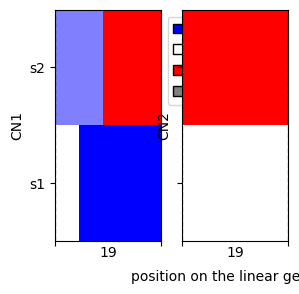

In [9]:
cns.fig_heatmap(agg_cns_df, cn_columns=['CN1', 'CN2']);

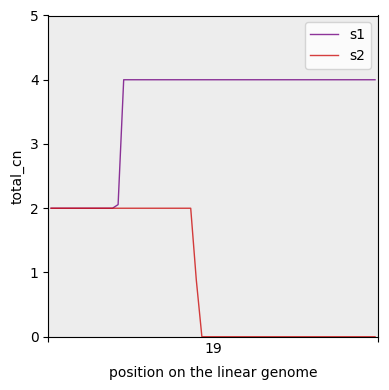

In [10]:
split_df = cns.main_seg_agg(imp_cns_df, split_size=1000000, remove_segs="gaps")
cns.fig_lines(cns.add_total_cn(split_df), cn_columns="total_cn");